In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Reusable function to apply clean plot styling
def apply_plot_style(ax, show_legend=True):
    """Apply consistent styling to a plot axis"""
    # Remove grid and background
    ax.grid(False)
    ax.set_facecolor('white')
    
    # Add black border around plot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    # Ticks pointing inward, only on left and bottom
    ax.tick_params(direction='in', length=6, width=1.5, colors='black',
                   which='both', top=False, right=False)
    
    # Style legend with rounded corners and light gray background
    if show_legend:
        legend = ax.legend(loc='best', fontsize=10, 
                          frameon=True, fancybox=True, shadow=False,
                          framealpha=0.95, edgecolor='black', facecolor='#f5f5f5')
        legend.get_frame().set_linewidth(1.0)

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

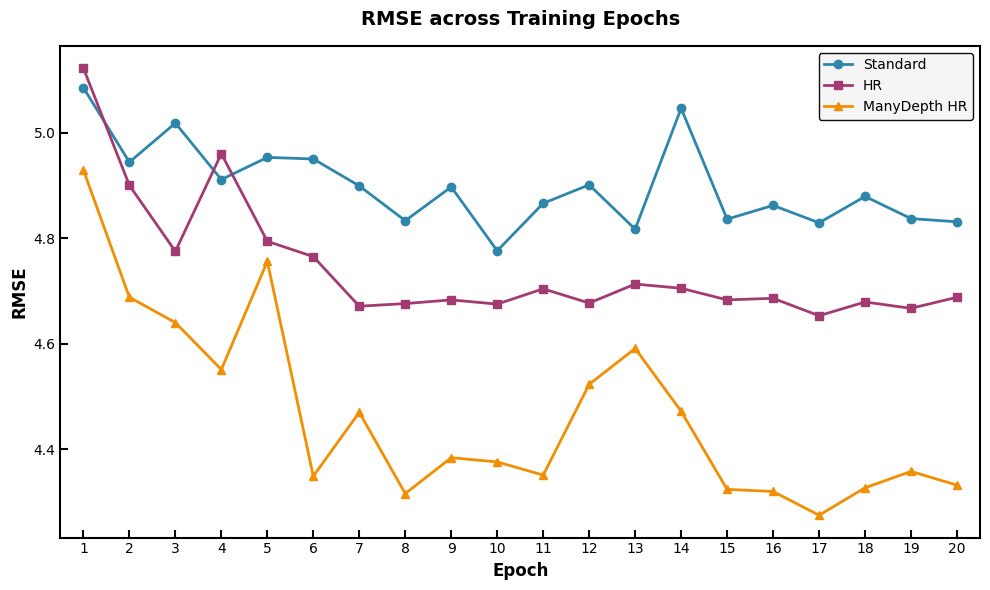

In [3]:
# Load the CSV files
csv_path = "results/evaluation_results.csv"
csv_path_hr = "results/evaluation_results_HR.csv"
csv_path_manydepth_hr = "results/evaluation_results_manydepthHR.csv"
df = pd.read_csv(csv_path)
df_hr = pd.read_csv(csv_path_hr)
df_manydepth_hr = pd.read_csv(csv_path_manydepth_hr)

# Add one to each epoch 
df['epoch'] = df['epoch'] + 1
df_hr['epoch'] = df_hr['epoch'] + 1
df_manydepth_hr['epoch'] = df_manydepth_hr['epoch'] + 1

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot RMSE across epochs for all three datasets
ax.plot(df['epoch'], df['rmse'], marker='o', linewidth=2, 
        markersize=6, color='#2E86AB', label='Standard')
ax.plot(df_hr['epoch'], df_hr['rmse'], marker='s', linewidth=2, 
        markersize=6, color='#A23B72', label='HR')
ax.plot(df_manydepth_hr['epoch'], df_manydepth_hr['rmse'], marker='^', linewidth=2, 
        markersize=6, color='#F18F01', label='ManyDepth HR')

# Labels and title
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('RMSE across Training Epochs', fontsize=14, fontweight='bold', pad=15)

# Set x-axis to show whole numbers from 1 to 20
ax.set_xticks(range(1, 21))
ax.set_xlim(0.5, 20.5)

# Apply the custom plot style
apply_plot_style(ax, show_legend=True)

plt.tight_layout()
plt.savefig("rmse_across_epochs.pdf")
plt.show()